# LightFM Feature Engineering

## Роль notebook

Этот notebook продолжает `02a_lightfm_hybrid_factorization.ipynb`.
Здесь мы не меняем класс модели и не меняем split.
Цель notebook: показать принцип работы с фичами в hybrid-модели: как их добавлять, как анализировать и как удалять лишние.


## План

- сохранить ту же offline-постановку, что и в `02a`;
- собрать несколько блоков item-features;
- посмотреть статистику признаков до обучения;
- обучить `LightFM` на нескольких feature sets;
- удалить часть шумных признаков и проверить, что изменится в метриках.


## Требование к окружению

Этот notebook должен использовать реальную библиотеку `lightfm`.
Если она не установлена, выполнение нужно остановить и сначала установить зависимость, например `pip install lightfm-next` для Python 3.12


In [1]:
import os

os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

warnings.filterwarnings("ignore", message="LightFM was compiled without OpenMP support.*", category=UserWarning)


def find_project_root(start_path: Path) -> Path:
    for candidate in [start_path, *start_path.parents]:
        if (candidate / "src" / "recsys_basics").exists():
            return candidate
    raise FileNotFoundError("Не удалось найти корень проекта с папкой src/recsys_basics")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
plt.style.use("ggplot")

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"SRC_DIR: {SRC_DIR}")


PROJECT_ROOT: /Users/bobrsubr/PycharmProjects/_researches/recommender-systems-from-zero
SRC_DIR: /Users/bobrsubr/PycharmProjects/_researches/recommender-systems-from-zero/src


In [2]:
try:
    from lightfm import LightFM
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "Библиотека `lightfm` не установлена. Установите её в окружение проекта (`pip install lightfm` или `pip install -r requirements.txt`) и перезапустите notebook."
    ) from exc

from recsys_basics.advanced.als import ImplicitALSRecommender
from recsys_basics.advanced.lightfm import (
    LightFMHybridRecommender,
    build_item_decade_feature_map,
    build_item_genre_feature_map,
    build_item_tag_feature_map,
    build_item_title_feature_map,
    merge_item_feature_maps,
    prune_item_feature_map,
)
from recsys_basics.basic.popularity import (
    PopularityRecommender,
    build_seen_items_map,
    filter_positive_explicit_feedback,
)
from recsys_basics.data import build_explicit_interactions, get_movielens_data_dir, load_movielens_frames
from recsys_basics.metrics import evaluate_ranking_metrics
from recsys_basics.split import assert_no_user_time_leakage, leave_last_two_out_split

DATA_DIR = get_movielens_data_dir()
MIN_RATING = 4.0
TOP_K = 10

frames = load_movielens_frames(DATA_DIR)
interactions_df = build_explicit_interactions(frames.ratings)
movies_df = frames.movies.rename(columns={"movieId": "item_id"}).copy()

print(f"Interactions loaded: {len(interactions_df):,}")
print(f"Movies loaded: {len(movies_df):,}")


Interactions loaded: 100,836
Movies loaded: 9,742


## Постановка остаётся той же

Чтобы результат можно было читать честно, сохраняем:

- тот же `MovieLens latest small`;
- тот же `implicit` сигнал из положительных рейтингов;
- тот же `train/validation/test` split;
- те же top-K метрики.

Здесь `train / validation / test` делятся не по фиксированным процентам, а по временной логике на пользователя.
Поэтому `validation` и `test` получаются маленькими по числу строк, но это нормально: их задача не занять условные `10%` датасета, а дать по одному честному отложенному примеру на каждого пользователя.

Меняем только набор item-features.


In [3]:
positive_df = filter_positive_explicit_feedback(interactions_df, min_rating=MIN_RATING)
split_result = leave_last_two_out_split(positive_df, min_user_interactions=3)
train_df = split_result.train
val_df = split_result.validation
test_df = split_result.test

assert_no_user_time_leakage(train_df, val_df)
assert_no_user_time_leakage(pd.concat([train_df, val_df], ignore_index=True), test_df)

split_summary = pd.DataFrame(
    {
        "metric": [
            "train_rows",
            "validation_rows",
            "test_rows",
            "train_users",
            "validation_users",
            "test_users",
            "train_items",
            "validation_items",
            "test_items",
        ],
        "value": [
            len(train_df),
            len(val_df),
            len(test_df),
            train_df["user_id"].nunique(),
            val_df["user_id"].nunique(),
            test_df["user_id"].nunique(),
            train_df["item_id"].nunique(),
            val_df["item_id"].nunique(),
            test_df["item_id"].nunique(),
        ],
    }
)

display(split_summary)


,metric,value
0,train_rows,47363
1,validation_rows,608
2,test_rows,608
3,train_users,608
4,validation_users,608
5,test_users,608
6,train_items,6227
7,validation_items,488
8,test_items,503


## Как добавлять признаки

Покажем это пошагово.
Сначала у нас есть только `genres`, а затем мы добавляем:

- `decade` из названия фильма;
- `title`-токены;
- `tags`, но только до train cutoff, чтобы не тащить future information.


In [4]:
if frames.tags is None:
    raise FileNotFoundError("Для feature engineering блока нужен `tags.csv` из MovieLens.")

tags_df = frames.tags.rename(columns={"movieId": "item_id"}).copy()
tags_df["timestamp"] = pd.to_datetime(tags_df["timestamp"], unit="s", utc=True)
train_cutoff = train_df["timestamp"].max()
train_time_tags_df = tags_df[tags_df["timestamp"] <= train_cutoff].copy()

genre_feature_map = build_item_genre_feature_map(movies_df)
decade_feature_map = build_item_decade_feature_map(movies_df)
title_feature_map = build_item_title_feature_map(movies_df, min_token_frequency=3)
tag_feature_map = build_item_tag_feature_map(train_time_tags_df, min_tag_frequency=3)

feature_maps = {
    "genres": genre_feature_map,
    "decade": decade_feature_map,
    "title": title_feature_map,
    "tags": tag_feature_map,
}

feature_sets = {
    "lightfm_genres": genre_feature_map,
    "lightfm_genres_decade": merge_item_feature_maps(genre_feature_map, decade_feature_map),
    "lightfm_genres_decade_title": merge_item_feature_maps(genre_feature_map, decade_feature_map, title_feature_map),
    "lightfm_full": merge_item_feature_maps(genre_feature_map, decade_feature_map, title_feature_map, tag_feature_map),
}

feature_preview = pd.DataFrame(
    [
        {
            "item_id": item_id,
            "title": movies_df.loc[movies_df["item_id"] == item_id, "title"].iloc[0],
            "genres": genre_feature_map.get(item_id, [])[:4],
            "title_tokens": title_feature_map.get(item_id, [])[:4],
            "tags": tag_feature_map.get(item_id, [])[:4],
        }
        for item_id in sorted(train_df["item_id"].unique().tolist())[:5]
    ]
)

print(f"Train cutoff for tags: {train_cutoff}")
display(feature_preview)


Train cutoff for tags: 2018-09-22 16:05:36+00:00


,item_id,title,genres,title_tokens,tags
0,1,Toy Story (1995),"[adventure, animation, children, comedy]","[title_story, title_toy]","[tag_fun, tag_pixar]"
1,2,Jumanji (1995),"[adventure, children, fantasy]",[],"[tag_fantasy, tag_robin_williams]"
2,3,Grumpier Old Men (1995),"[comedy, romance]","[title_men, title_old]",[]
3,5,Father of the Bride Part II (1995),[comedy],"[title_bride, title_father]","[tag_pregnancy, tag_remake]"
4,6,Heat (1995),"[action, crime, thriller]",[title_heat],[]


## Как анализировать признаки до обучения

До запуска модели полезно посмотреть хотя бы на три вещи:

- coverage: сколько объектов вообще покрыто признаками;
- sparsity: сколько уникальных токенов и сколько признаков в среднем на объект;
- шум: слишком редкие токены, которые могут не помогать модели.


In [5]:
def summarize_feature_map(name: str, feature_map: dict[int, list[str]]) -> dict[str, float | int | str]:
    tokens_by_item = [len(tokens) for tokens in feature_map.values()]
    unique_tokens = sorted({token for tokens in feature_map.values() for token in tokens})
    items_with_features = sum(1 for tokens in feature_map.values() if tokens)
    return {
        "feature_block": name,
        "items_with_features": int(items_with_features),
        "coverage_ratio": items_with_features / max(len(feature_map), 1),
        "unique_tokens": int(len(unique_tokens)),
        "avg_tokens_per_item": sum(tokens_by_item) / max(len(tokens_by_item), 1),
    }


def token_support_table(feature_map: dict[int, list[str]], prefix: str | None = None) -> pd.DataFrame:
    rows = []
    for item_id, tokens in feature_map.items():
        for token in set(tokens):
            if prefix is not None and not token.startswith(prefix):
                continue
            rows.append({"item_id": item_id, "token": token})
    if not rows:
        return pd.DataFrame(columns=["token", "item_support"])
    support = pd.DataFrame(rows).groupby("token").size().rename("item_support").reset_index()
    return support.sort_values(["item_support", "token"], ascending=[False, True]).reset_index(drop=True)

source_summary = pd.DataFrame(
    [summarize_feature_map(name, fmap) for name, fmap in feature_maps.items()]
)

title_support = token_support_table(title_feature_map, prefix="title_")
tag_support = token_support_table(tag_feature_map, prefix="tag_")

analysis_summary = pd.DataFrame(
    {
        "check": [
            "title_tokens_top10_support",
            "title_tokens_with_support_lt_5",
            "tag_tokens_top10_support",
            "tag_tokens_with_support_lt_5",
        ],
        "value": [
            int(title_support.head(10)["item_support"].sum()) if not title_support.empty else 0,
            int((title_support["item_support"] < 5).sum()) if not title_support.empty else 0,
            int(tag_support.head(10)["item_support"].sum()) if not tag_support.empty else 0,
            int((tag_support["item_support"] < 5).sum()) if not tag_support.empty else 0,
        ],
    }
)

display(source_summary)
display(analysis_summary)
display(title_support.head(15))
display(tag_support.head(15))


,feature_block,items_with_features,coverage_ratio,unique_tokens,avg_tokens_per_item
0,genres,9742,1.0000,20,2.2669
1,decade,9729,0.9987,12,0.9987
2,title,7605,0.7806,1934,1.6401
3,tags,1205,1.0000,325,1.8357


,check,value
0,title_tokens_top10_support,1001
1,title_tokens_with_support_lt_5,928
2,tag_tokens_top10_support,339
3,tag_tokens_with_support_lt_5,148


,token,item_support
0,title_man,186
1,title_love,107
2,title_la,100
3,title_my,95
4,title_movie,93
5,title_no,88
6,title_night,86
7,title_you,86
8,title_me,80
9,title_story,80


,token,item_support
0,tag_in_netflix_queue,131
1,tag_atmospheric,37
2,tag_disney,22
3,tag_funny,22
4,tag_quirky,22
5,tag_religion,22
6,tag_superhero,22
7,tag_surreal,22
8,tag_thought_provoking,20
9,tag_comedy,19


## Как удалять лишние признаки

В этом notebook мы не используем `SHAP` как основной инструмент.
Для factorization-модели полезнее сначала убрать очевидный шум:

- слишком редкие `title_` и `tag_` токены;
- слишком массовые `title_` и `tag_` токены, если они начинают работать как почти пустые признаки.

Жанры и десятилетия оставляем как более устойчивые базовые признаки.


In [6]:
full_feature_map = feature_sets["lightfm_full"]
pruned_feature_map = prune_item_feature_map(
    full_feature_map,
    min_item_frequency=5,
    max_item_frequency_ratio=0.35,
    prunable_prefixes=("title_", "tag_"),
)
feature_sets["lightfm_pruned"] = pruned_feature_map

full_tokens = sorted({token for tokens in full_feature_map.values() for token in tokens})
pruned_tokens = sorted({token for tokens in pruned_feature_map.values() for token in tokens})
removed_tokens = sorted(set(full_tokens) - set(pruned_tokens))

prune_summary = pd.DataFrame(
    {
        "metric": [
            "full_tokens",
            "pruned_tokens",
            "removed_tokens",
            "items_with_any_feature_before",
            "items_with_any_feature_after",
        ],
        "value": [
            len(full_tokens),
            len(pruned_tokens),
            len(removed_tokens),
            sum(1 for tokens in full_feature_map.values() if tokens),
            sum(1 for tokens in pruned_feature_map.values() if tokens),
        ],
    }
)

removed_preview = pd.DataFrame({"removed_tokens": removed_tokens[:20]})

display(prune_summary)
display(removed_preview)


,metric,value
0,full_tokens,2291
1,pruned_tokens,1215
2,removed_tokens,1076
3,items_with_any_feature_before,9742
4,items_with_any_feature_after,9742


,removed_tokens
0,tag_06_oscar_nominated_best_movie_animation
1,tag_1970s
2,tag_alfred_hitchcock
3,tag_alternate_reality
4,tag_anti_semitism
5,tag_archaeology
6,tag_artistic
7,tag_artsy
8,tag_assassin
9,tag_awesome


## Сравниваем feature sets

Теперь у нас есть несколько осмысленных шагов:

- `lightfm_genres`;
- `lightfm_genres_decade`;
- `lightfm_genres_decade_title`;
- `lightfm_full`;
- `lightfm_pruned`.

Это позволяет показать не только финальную цифру, но и сам процесс работы с признаками.


In [7]:
seen_items_map = build_seen_items_map(train_df)
all_user_ids = sorted(val_df["user_id"].unique().tolist())

popularity_model = PopularityRecommender().fit(train_df)
als_model = ImplicitALSRecommender(
    n_factors=16,
    n_iterations=8,
    regularization=0.1,
    alpha=20.0,
    random_state=42,
).fit(train_df)

popularity_recs = popularity_model.recommend_many(all_user_ids, seen_items_map=seen_items_map, k=TOP_K)
als_recs = als_model.recommend_many(all_user_ids, seen_items_map=seen_items_map, k=TOP_K)


def summarize_metrics(name: str, recommendations: pd.DataFrame, k: int = TOP_K) -> dict[str, float | str]:
    metrics_df = evaluate_ranking_metrics(val_df, recommendations, k=k)
    unique_items = recommendations["item_id"].nunique() if not recommendations.empty else 0
    catalog_items = train_df["item_id"].nunique()
    summary = {"model": name}
    for column in metrics_df.columns:
        if column == "user_id":
            continue
        summary[column] = float(metrics_df[column].mean())
    summary["catalog_coverage"] = unique_items / catalog_items if catalog_items else 0.0
    summary["unique_recommended_items"] = int(unique_items)
    return summary

rows = [summarize_metrics("als", als_recs)]
recommendations_by_model = {"als": als_recs, "popularity": popularity_recs}

for model_name, feature_map in feature_sets.items():
    model = LightFMHybridRecommender(
        no_components=16,
        loss="warp",
        learning_rate=0.05,
        item_alpha=1e-6,
        user_alpha=1e-6,
        epochs=15,
        num_threads=1,
        random_state=42,
    ).fit(train_df, item_features=feature_map)
    recs = model.recommend_many(all_user_ids, seen_items_map=seen_items_map, k=TOP_K)
    recommendations_by_model[model_name] = recs
    row = summarize_metrics(model_name, recs)
    row["feature_tokens"] = len({token for tokens in feature_map.values() for token in tokens})
    row["avg_tokens_per_item"] = sum(len(tokens) for tokens in feature_map.values()) / max(len(feature_map), 1)
    rows.append(row)

feature_step_summary = pd.DataFrame(rows)
display(feature_step_summary)


  0%|          | 0/8 [00:00<?, ?it/s]

,model,precision@10,recall@10,hit_rate@10,map@10,ndcg@10,catalog_coverage,unique_recommended_items,feature_tokens,avg_tokens_per_item
0,als,0.0064,0.0641,0.0641,0.0208,0.0309,0.1200,747,NaN,NaN
1,lightfm_genres,0.0064,0.0641,0.0641,0.0189,0.0293,0.0764,476,20.0000,2.2669
2,lightfm_genres_decade,0.0074,0.0740,0.0740,0.0238,0.0353,0.0814,507,32.0000,3.2656
3,lightfm_genres_decade_title,0.0061,0.0609,0.0609,0.0190,0.0286,0.0888,553,"1,966.0000",4.9057
4,lightfm_full,0.0058,0.0576,0.0576,0.0256,0.0331,0.0888,553,"2,291.0000",5.1327
5,lightfm_pruned,0.0054,0.0543,0.0543,0.0187,0.0270,0.0864,538,"1,215.0000",4.7630


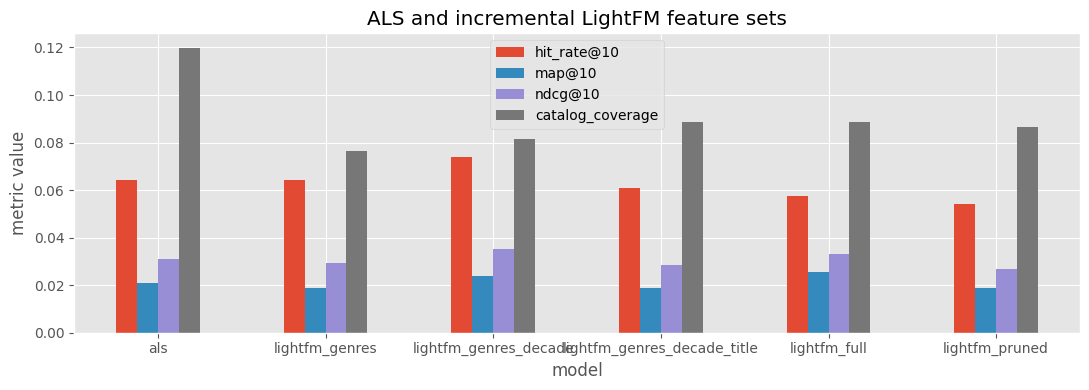

In [8]:
plot_df = feature_step_summary.set_index("model")[["hit_rate@10", "map@10", "ndcg@10", "catalog_coverage"]]
plot_df.plot(kind="bar", figsize=(11, 4), rot=0, title="ALS and incremental LightFM feature sets")
plt.ylabel("metric value")
plt.tight_layout()
plt.show()


## Как интерпретировать результат

В этом validation-прогоне лучший прирост дал не самый большой набор признаков, а умеренное расширение `genres` через `decade`.

Это видно по результатам:

- `lightfm_genres_decade` стал лучшей версией `LightFM` по `precision@10`, `recall@10`, `hit_rate@10` и `NDCG@10`;
- `lightfm_full` оказался лучшим по `MAP@10`, но не по остальным ranking-метрикам;
- `title`-токены и добавление всех признаков сразу не дали автоматического выигрыша;
- pruning убрал часть шума, но в этом прогоне не дал лучшую конфигурацию.

Диагностика признаков помогает это объяснить:

- небольшой и понятный блок признаков иногда работает лучше, чем большой набор токенов;
- часть `title` и `tag`-признаков добавляет не только сигнал, но и шум;
- разные метрики могут расходиться, поэтому смотреть нужно не на одну цифру, а на профиль качества целиком.

Итоговый учебный вывод такой:

- признаки нужно добавлять по блокам, а не одним большим пакетом;
- каждый новый блок нужно проверять отдельно по offline-метрикам на `validation`;
- статистика признаков помогает понять, какие блоки выглядят полезными, а какие только увеличивают шум;
- удалять признаки лучше не “на глаз”, а через сочетание диагностики и итогового влияния на качество;
- `test` остаётся нетронутым и пригодится дальше для более строгой финальной проверки.


## Что дальше

Следующий шаг в маршруте: [02c_lightfm_hyperparameter_tuning.ipynb](/Users/bobrsubr/PycharmProjects/_researches/recommender-systems-from-zero/notebooks/advanced/02c_lightfm_hyperparameter_tuning.ipynb).

Там мы сохраним feature engineering результат и посмотрим, сколько качества можно вернуть уже через настройку самой модели.
